In [29]:
import os

import imageio
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import datasets
from torchvision import transforms
import torch.nn.functional as F
import torch.optim as optim



%matplotlib inline

In [7]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=False)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [27]:
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, num_classes):
        super(ConditionalVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Энкодер
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + num_classes, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        
        # Слои для mu и log_var
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_var = nn.Linear(256, latent_dim)
        
        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )
    
    def encode(self, x, c):
        # Конкатенируем вход и one-hot представление класса
        c_onehot = F.one_hot(c, num_classes=self.num_classes).float()
        x = torch.cat([x, c_onehot], dim=1)
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, c):
        # Конкатенируем латентный вектор и one-hot представление класса
        c_onehot = F.one_hot(c, num_classes=self.num_classes).float()
        z = torch.cat([z, c_onehot], dim=1)
        return self.decoder(z)
    
    def forward(self, x, c):
        mu, log_var = self.encode(x.view(-1, input_dim), c)
        z = self.reparameterize(mu, log_var)
        return self.decode(z, c), mu, log_var


In [28]:
batch_size = 128
latent_dim = 2
num_classes = 10
input_dim = 784  # 28x28
epochs = 20
learning_rate = 1e-3

In [37]:
# Функция потерь
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, input_dim), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


#### Обучение

In [38]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [39]:
# Инициализация модели
model = ConditionalVAE(input_dim, latent_dim, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [40]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, labels)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
    
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')


In [41]:
# Генерация примеров
def generate_samples(num_samples=10):
    model.eval()
    with torch.no_grad():
        # Создаем латентные векторы
        z = torch.randn(num_samples, latent_dim).to(device)
        
        # Создаем метки классов от 0 до 9
        labels = torch.arange(0, num_classes).to(device)
        
        samples = model.decode(z, labels).cpu()
        
        # Визуализация
        fig, axes = plt.subplots(1, num_samples, figsize=(20, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].view(28, 28).numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'Class: {i}')
        plt.show()

Train Epoch: 1 [0/60000 (0%)]	Loss: 543.315063
Train Epoch: 1 [3200/60000 (5%)]	Loss: 174.302856
Train Epoch: 1 [6400/60000 (11%)]	Loss: 162.894348
Train Epoch: 1 [9600/60000 (16%)]	Loss: 155.837891
Train Epoch: 1 [12800/60000 (21%)]	Loss: 150.649216
Train Epoch: 1 [16000/60000 (27%)]	Loss: 145.620285
Train Epoch: 1 [19200/60000 (32%)]	Loss: 153.219452
Train Epoch: 1 [22400/60000 (37%)]	Loss: 149.809784
Train Epoch: 1 [25600/60000 (43%)]	Loss: 139.544327
Train Epoch: 1 [28800/60000 (48%)]	Loss: 146.398773
Train Epoch: 1 [32000/60000 (53%)]	Loss: 145.739594
Train Epoch: 1 [35200/60000 (59%)]	Loss: 143.514084
Train Epoch: 1 [38400/60000 (64%)]	Loss: 154.060013
Train Epoch: 1 [41600/60000 (69%)]	Loss: 144.325836
Train Epoch: 1 [44800/60000 (75%)]	Loss: 132.661270
Train Epoch: 1 [48000/60000 (80%)]	Loss: 155.223221
Train Epoch: 1 [51200/60000 (85%)]	Loss: 146.504959
Train Epoch: 1 [54400/60000 (91%)]	Loss: 141.047363
Train Epoch: 1 [57600/60000 (96%)]	Loss: 130.536285
====> Epoch: 1 Averag

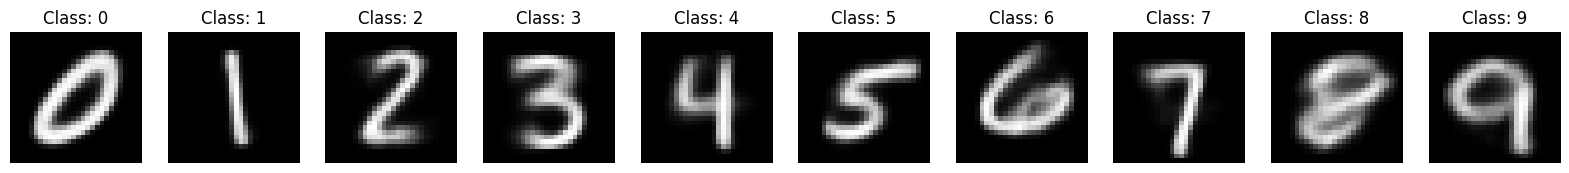

Train Epoch: 6 [0/60000 (0%)]	Loss: 120.397896
Train Epoch: 6 [3200/60000 (5%)]	Loss: 132.769104
Train Epoch: 6 [6400/60000 (11%)]	Loss: 118.753250
Train Epoch: 6 [9600/60000 (16%)]	Loss: 116.356735
Train Epoch: 6 [12800/60000 (21%)]	Loss: 126.746353
Train Epoch: 6 [16000/60000 (27%)]	Loss: 135.129166
Train Epoch: 6 [19200/60000 (32%)]	Loss: 121.125198
Train Epoch: 6 [22400/60000 (37%)]	Loss: 140.738800
Train Epoch: 6 [25600/60000 (43%)]	Loss: 132.645859
Train Epoch: 6 [28800/60000 (48%)]	Loss: 134.263428
Train Epoch: 6 [32000/60000 (53%)]	Loss: 135.992722
Train Epoch: 6 [35200/60000 (59%)]	Loss: 143.353821
Train Epoch: 6 [38400/60000 (64%)]	Loss: 128.001114
Train Epoch: 6 [41600/60000 (69%)]	Loss: 131.468597
Train Epoch: 6 [44800/60000 (75%)]	Loss: 131.116516
Train Epoch: 6 [48000/60000 (80%)]	Loss: 134.891998
Train Epoch: 6 [51200/60000 (85%)]	Loss: 141.931152
Train Epoch: 6 [54400/60000 (91%)]	Loss: 123.839569
Train Epoch: 6 [57600/60000 (96%)]	Loss: 119.086517
====> Epoch: 6 Averag

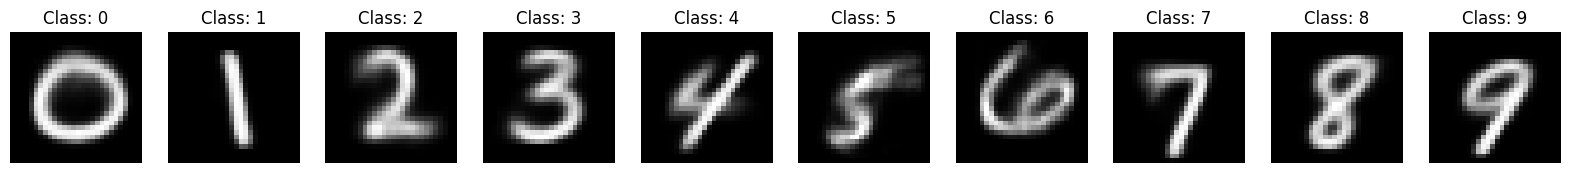

Train Epoch: 11 [0/60000 (0%)]	Loss: 128.072449
Train Epoch: 11 [3200/60000 (5%)]	Loss: 133.463196
Train Epoch: 11 [6400/60000 (11%)]	Loss: 121.624985
Train Epoch: 11 [9600/60000 (16%)]	Loss: 129.440140
Train Epoch: 11 [12800/60000 (21%)]	Loss: 141.091568
Train Epoch: 11 [16000/60000 (27%)]	Loss: 139.555878
Train Epoch: 11 [19200/60000 (32%)]	Loss: 119.760506
Train Epoch: 11 [22400/60000 (37%)]	Loss: 131.378296
Train Epoch: 11 [25600/60000 (43%)]	Loss: 119.045578
Train Epoch: 11 [28800/60000 (48%)]	Loss: 121.529488
Train Epoch: 11 [32000/60000 (53%)]	Loss: 134.637634
Train Epoch: 11 [35200/60000 (59%)]	Loss: 133.014999
Train Epoch: 11 [38400/60000 (64%)]	Loss: 128.241760
Train Epoch: 11 [41600/60000 (69%)]	Loss: 121.151932
Train Epoch: 11 [44800/60000 (75%)]	Loss: 125.065018
Train Epoch: 11 [48000/60000 (80%)]	Loss: 127.347878
Train Epoch: 11 [51200/60000 (85%)]	Loss: 137.715652
Train Epoch: 11 [54400/60000 (91%)]	Loss: 138.192245
Train Epoch: 11 [57600/60000 (96%)]	Loss: 134.956757
==

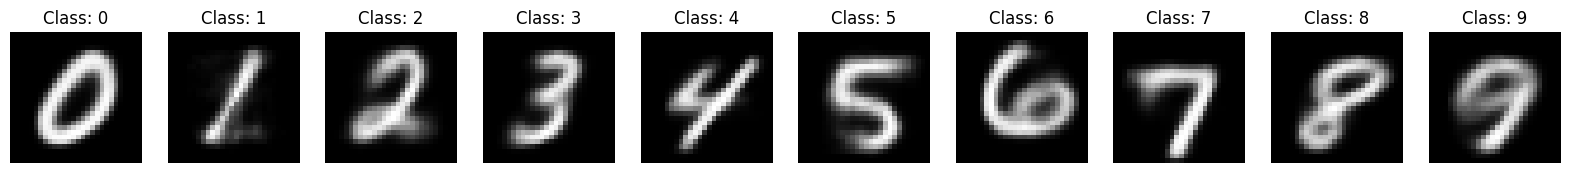

Train Epoch: 16 [0/60000 (0%)]	Loss: 132.373062
Train Epoch: 16 [3200/60000 (5%)]	Loss: 118.619690
Train Epoch: 16 [6400/60000 (11%)]	Loss: 124.722160
Train Epoch: 16 [9600/60000 (16%)]	Loss: 115.238800
Train Epoch: 16 [12800/60000 (21%)]	Loss: 129.439240
Train Epoch: 16 [16000/60000 (27%)]	Loss: 124.612885
Train Epoch: 16 [19200/60000 (32%)]	Loss: 123.260445
Train Epoch: 16 [22400/60000 (37%)]	Loss: 124.006241
Train Epoch: 16 [25600/60000 (43%)]	Loss: 141.835968
Train Epoch: 16 [28800/60000 (48%)]	Loss: 130.240738
Train Epoch: 16 [32000/60000 (53%)]	Loss: 132.091965
Train Epoch: 16 [35200/60000 (59%)]	Loss: 119.040977
Train Epoch: 16 [38400/60000 (64%)]	Loss: 121.831802
Train Epoch: 16 [41600/60000 (69%)]	Loss: 138.248886
Train Epoch: 16 [44800/60000 (75%)]	Loss: 117.499588
Train Epoch: 16 [48000/60000 (80%)]	Loss: 115.222382
Train Epoch: 16 [51200/60000 (85%)]	Loss: 121.745155
Train Epoch: 16 [54400/60000 (91%)]	Loss: 123.960365
Train Epoch: 16 [57600/60000 (96%)]	Loss: 133.646317
==

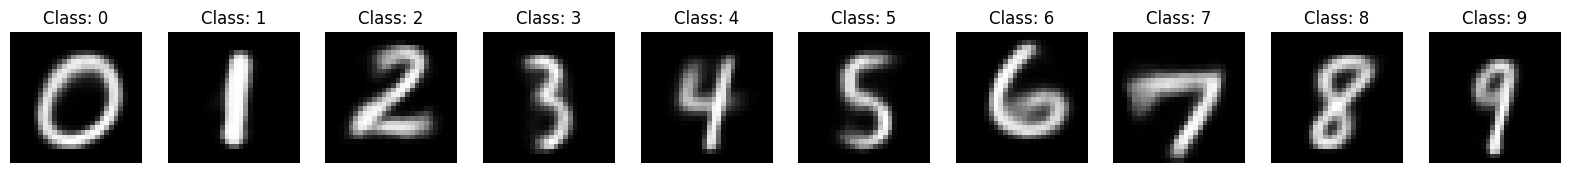

In [42]:
# Запуск обучения
for epoch in range(1, epochs + 1):
    train(epoch)
    if epoch % 5 == 0:
        generate_samples()

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Генерация разных цифр из одного латентного вектора
def generate_same_latent_different_classes(model, latent_dim, device, num_classes=10):
    model.eval()
    with torch.no_grad():
        # Создаем ОДИН латентный вектор
        z = torch.randn(1, latent_dim).to(device)
        # Дублируем его для всех классов
        z = z.repeat(num_classes, 1)
        
        # Создаем метки классов от 0 до 9
        labels = torch.arange(0, num_classes).to(device)
        
        # Генерируем изображения
        samples = model.decode(z, labels).cpu()
        
        # Визуализация
        fig, axes = plt.subplots(1, num_classes, figsize=(20, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].view(28, 28).numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'Class: {i}')
        plt.show()



In [44]:

# Пример для конкретных классов (например, 5 и 7)
def generate_specific_classes_from_same_latent(model, latent_dim, device, classes=[5, 7]):
    model.eval()
    with torch.no_grad():
        # Создаем один латентный вектор
        z = torch.randn(1, latent_dim).to(device)
        # Дублируем его для нужных классов
        z = z.repeat(len(classes), 1)
        
        # Создаем метки для конкретных классов
        labels = torch.tensor(classes).to(device)
        
        # Генерируем изображения
        samples = model.decode(z, labels).cpu()
        
        # Визуализация
        fig, axes = plt.subplots(1, len(classes), figsize=(6, 2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i].view(28, 28).numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'Class: {classes[i]}')
        plt.show()



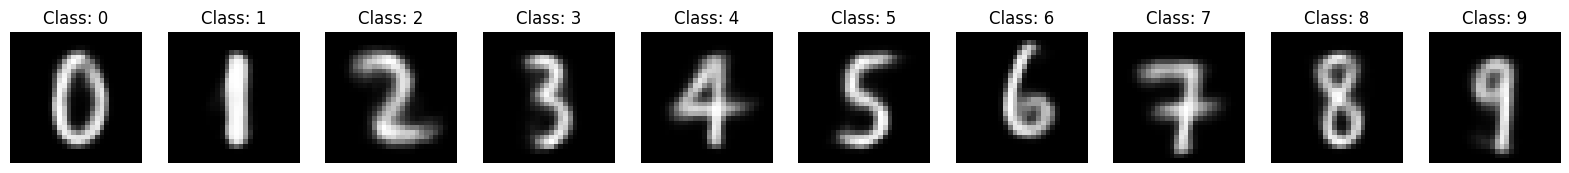

In [51]:
generate_same_latent_different_classes(model, latent_dim, device)

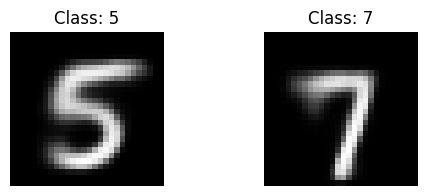

In [52]:
# Генерируем цифры 5 и 7 из одного латентного вектора
generate_specific_classes_from_same_latent(model, latent_dim, device, classes=[5, 7])

Splendid! Вы великолепны!


> Хотя мы взяли один вектор из латентного пространства, Нам удалось восстановить изображения. Можно увидеть что все цифры обладают схожим стилем, который и определяет вектор

### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [55]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_latent_2d_cvae(model, data_loader, num_batches=100, device='cuda'):
    model.eval()
    all_mu = []
    all_labels = []
    
    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            if i >= num_batches:
                break
                
            # Подготавливаем данные с учетом класса
            x = x.view(-1, 784).to(device)
            c = y.to(device)
            c_onehot = F.one_hot(c, num_classes=10).float()
            x_c = torch.cat([x, c_onehot], dim=1)
            
            # Получаем латентные представления
            h = model.encoder(x_c)
            mu = model.fc_mu(h)  # [batch_size, 2]
            
            all_mu.append(mu.cpu())
            all_labels.append(y.cpu())
    
    # Объединяем все батчи
    latents = torch.cat(all_mu, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    
    # Визуализация
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.colorbar(scatter, ticks=range(10), label='Digit Class')
    plt.title('2D Latent Space of CVAE (colored by digit class)')
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    
    # Опционально: добавить примеры цифр в соответствующих точках
    for digit in range(10):
        idx = np.where(labels == digit)[0]
        if len(idx) > 0:
            # Берем ближайшую к центру точку для каждого класса
            center = np.mean(latents[idx], axis=0)
            dists = np.sum((latents[idx] - center)**2, axis=1)
            closest_idx = idx[np.argmin(dists)]
            
            # Вставляем пример цифры
            example = next((x for x, y in data_loader if y[0] == digit), None)
            if example is not None:
                digit_img = example[0][0].squeeze().numpy()
                imagebox = OffsetImage(digit_img, cmap='gray', zoom=0.5)
                ab = AnnotationBbox(imagebox, (latents[closest_idx, 0], latents[closest_idx, 1]), 
                                  frameon=False, pad=0)
                plt.gca().add_artist(ab)
    
    plt.grid(alpha=0.3)
    plt.show()


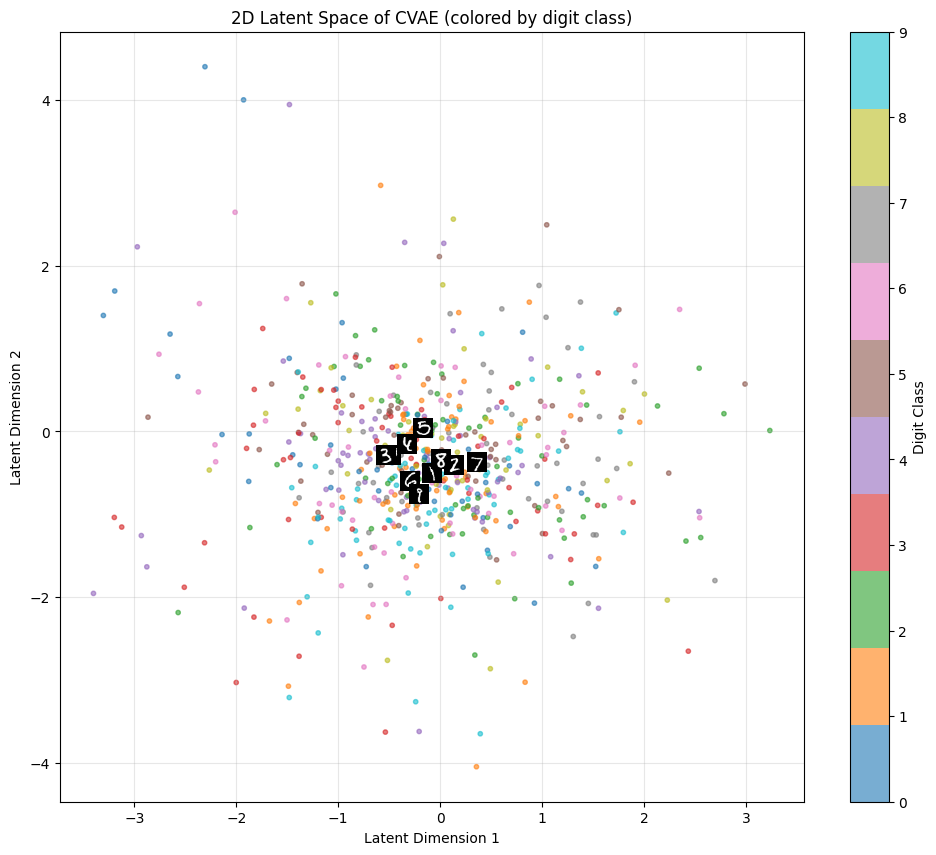

In [56]:

# Для использования:
plot_latent_2d_cvae(model, test_loader, num_batches=20, device=device)

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

> Вектора имеют относительно равномерное распределение. Для примера расставил картинки с примерами цифр, но видно что они ни к чему не привязаны.